<a href="https://colab.research.google.com/github/Thalitarouth/Machine-Learning/blob/main/Decomposi%C3%A7%C3%A3o_de_series_temporais.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **Prever padrões sazonais nas movimentações de carga  com decomposição de séries temporais: Usando decomposição sazonal ou modelo STL, o modelo identifica padrões sazonais e Tonelagem e TEUs com base em dados mensais históricos, sem necessidade de dados externos, para planejar operações de baixa demanda.**

# **1. Introdução**

A decomposição de séries temporais é um processo que divide a série original em três componentes essenciais:

**Tendência (Trend)**: Refere-se à direção geral dos dados ao longo do tempo, como um crescimento constante ou uma diminuição.

**Sazonalidade** (Seasonality): São padrões que se repetem em intervalos regulares, como picos mensais ou trimestrais.

**Resíduo** (Residual / Noise): Representa o que sobra após a remoção da tendência e da sazonalidade. Idealmente, deve se comportar como ruído branco, ou seja, sem um padrão claro.

Existem diferentes modelos para realizar essa decomposição:

**Modelo Aditivo**: Assume que os componentes são somados, sendo recomendado quando a variação sazonal é constante ao longo do tempo.

Fórmula: série = tendência + sazonalidade + ruído

**Modelo Multiplicativo:** Assume que os componentes se multiplicam, indicado quando a sazonalidade cresce proporcionalmente à tendência.

Fórmula: série = tendência × sazonalidade × ruído

**STL** (Seasonal and Trend using Loess): Método mais moderno e robusto, que utiliza suavização local para separar os componentes. Ele é eficaz para lidar com padrões não lineares e irregulares.

In [ ]:
!pip install statsmodels
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.tsa.stattools import adfuller
import matplotlib.dates as mdates

# Leitura dos dados
df = pd.read_excel('Dados_completos.xlsx')

# Pré-processamento
df["data"] = pd.to_datetime(df["ano"].astype(str) + "-" + df["mes"].astype(str).str.zfill(2) + "-01")
df = df[df["ano"].between(2020, 2024)]

# Agrupamento mensal
df_monthly = df.groupby("data").agg({"toneladas": "sum", "TEUs": "sum"}).sort_index()


# **2. Análise Exploratória dos dados**

Visualizar a quantidade de linhas e colunas

In [ ]:
(df.shape)

(77987, 14)

Visualização dos meses de baixa movimentação em Toneladas

Text(0.5, 0.98, '')

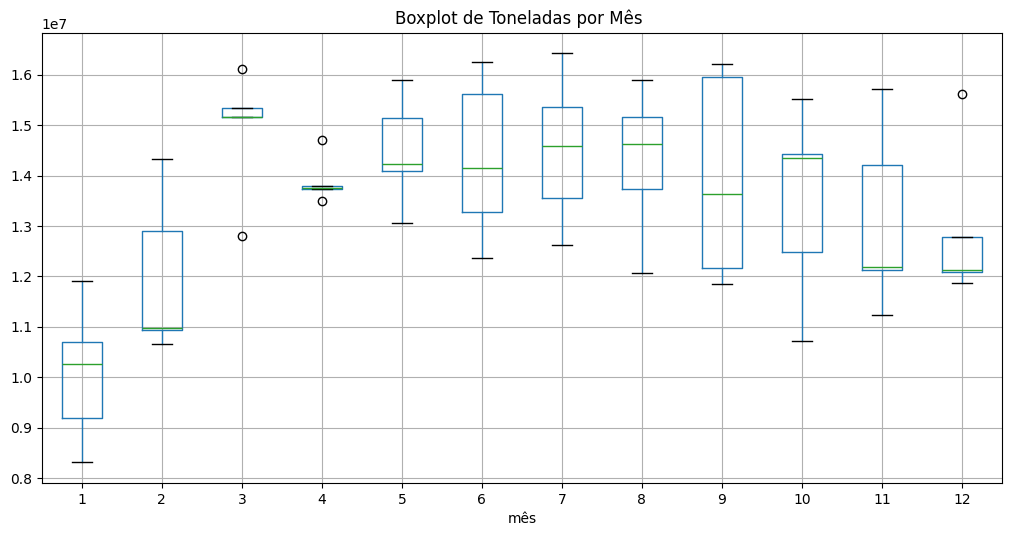

In [ ]:
import matplotlib.pyplot as plt
df_monthly["mês"] = df_monthly.index.month
df_monthly.boxplot(column="toneladas", by="mês", figsize=(12,6))
plt.title("Boxplot de Toneladas por Mês ")
plt.suptitle("")

Confirmação em gráfico de barras Toneladas

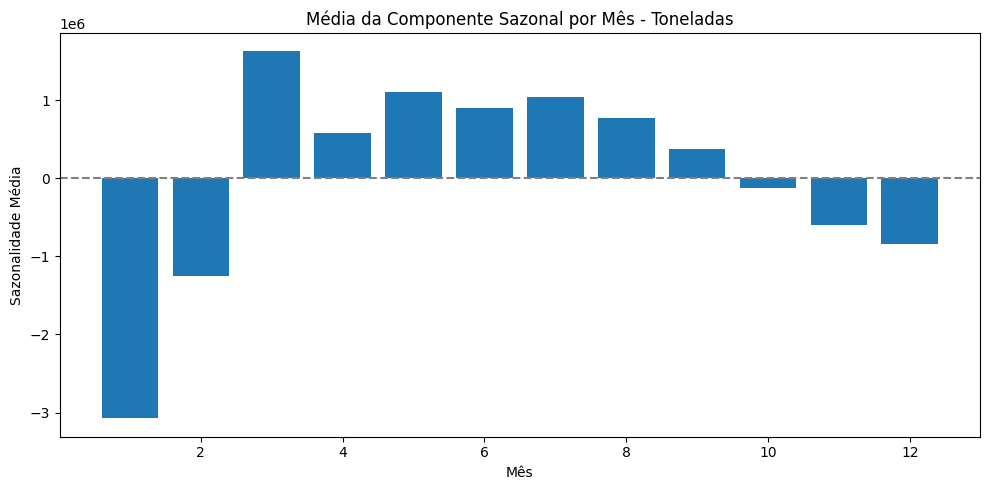

In [ ]:
# Criar gráfico de barras com a média da sazonalidade por mês
plt.figure(figsize=(10, 5))

# Realizar a decomposição STL para a série temporal 'toneladas'
# O parâmetro seasonal=13 é um exemplo e pode precisar ser ajustado com base na sua sazonalidade
stl_result_toneladas = STL(df_monthly["toneladas"], seasonal=13).fit()

# Calcular a média da componente sazonal por mês
df_monthly["sazonal_toneladas"] = stl_result_toneladas.seasonal
sazonal_por_mes = df_monthly.groupby(df_monthly.index.month)["sazonal_toneladas"].mean()

# Plotar o gráfico de barras
plt.bar(sazonal_por_mes.index, sazonal_por_mes.values)
plt.title("Média da Componente Sazonal por Mês - Toneladas")
plt.xlabel("Mês")
plt.ylabel("Sazonalidade Média")
plt.axhline(0, color='gray', linestyle='--')
plt.tight_layout()
plt.show()

Visualização dos meses de baixa movimentação em TEUs

Text(0.5, 0.98, '')

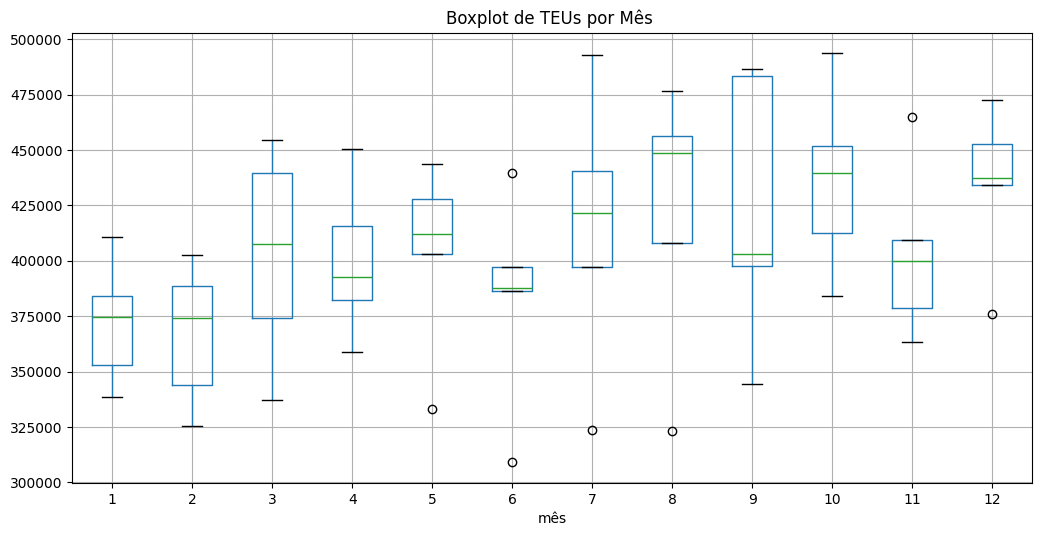

In [ ]:
import matplotlib.pyplot as plt
df_monthly["mês"] = df_monthly.index.month
df_monthly.boxplot(column="TEUs", by="mês", figsize=(12,6))
plt.title("Boxplot de TEUs por Mês ")
plt.suptitle("")

Confirmação em gráfico de barras TEUs

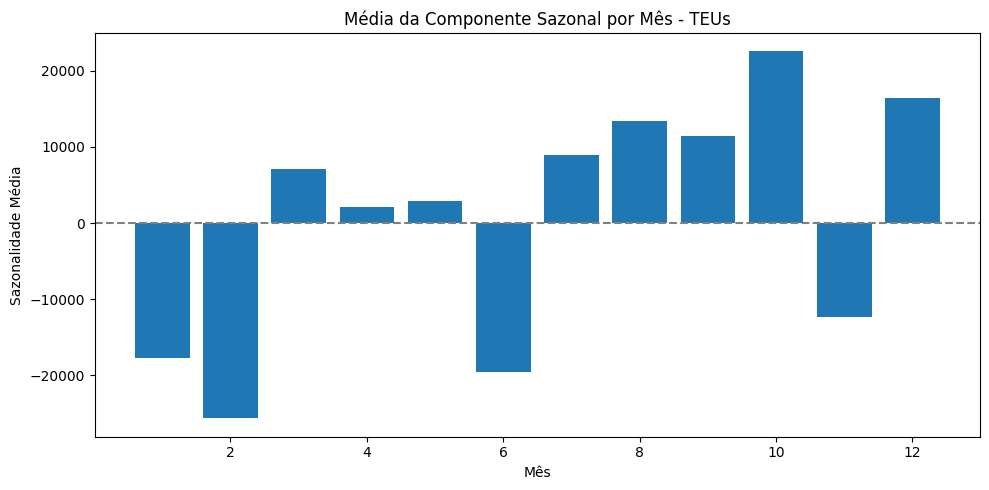

In [ ]:
# Criar gráfico de barras com a média da sazonalidade por mês
plt.figure(figsize=(10, 5))

# Realizar a decomposição STL para a série temporal 'toneladas'
# O parâmetro seasonal=13 é um exemplo e pode precisar ser ajustado com base na sua sazonalidade
stl_result_toneladas = STL(df_monthly["TEUs"], seasonal=13).fit()

# Calcular a média da componente sazonal por mês
df_monthly["sazonal_TEUs"] = stl_result_toneladas.seasonal
sazonal_por_mes = df_monthly.groupby(df_monthly.index.month)["sazonal_TEUs"].mean()

# Plotar o gráfico de barras
plt.bar(sazonal_por_mes.index, sazonal_por_mes.values)
plt.title("Média da Componente Sazonal por Mês - TEUs")
plt.xlabel("Mês")
plt.ylabel("Sazonalidade Média")
plt.axhline(0, color='gray', linestyle='--')
plt.tight_layout()
plt.show()

## **3. Decomposição de séries temporais**

3.1 Decomposição clássica Aditiva em Toneladas

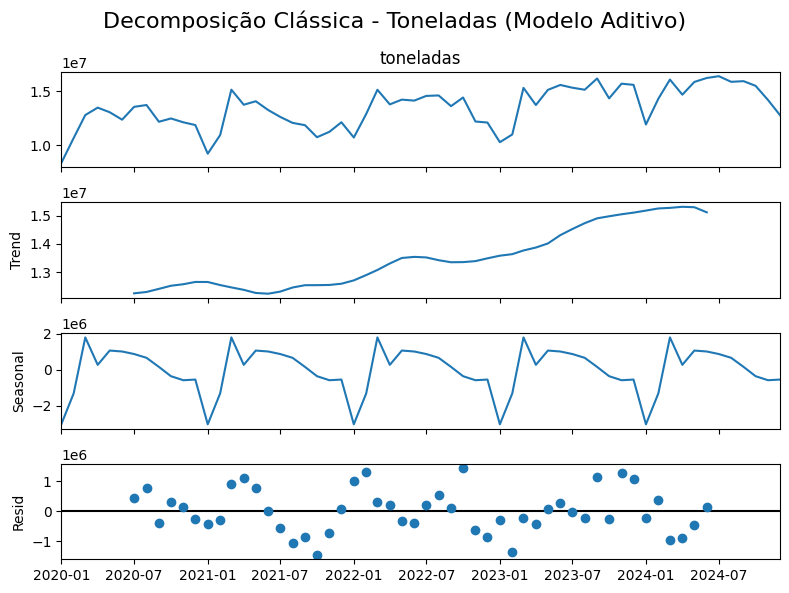

In [ ]:
# Decomposição clássica (aditiva)
decomp_add = seasonal_decompose(df_monthly["toneladas"], model="additive", period=12)

# Decomposição STL
stl = STL(df_monthly["toneladas"], period=12)
res_stl = stl.fit()

# Teste de estacionariedade ADF nos resíduos do modelo STL
adf_result = adfuller(res_stl.resid.dropna())
adf_statistic = adf_result[0]
adf_pvalue = adf_result[1]

# Organizando os resultados para exibição ao usuário
results_summary = {
    "ADF Statistic (STL Residuals)": adf_statistic,
    "p-value": adf_pvalue,
    "Conclusion": "Estacionária" if adf_pvalue < 0.05 else "Não Estacionária"
}

# Import ace_tools is not needed and can be removed
# import ace_tools as tools; tools.display_dataframe_to_user(name="Resumo do Teste de Estacionariedade (ADF)", dataframe=pd.DataFrame([results_summary]))

# Display the dataframe directly
pd.DataFrame([results_summary])

# Visualização da decomposição clássica
fig = decomp_add.plot()
fig.set_size_inches(8, 6)
plt.suptitle("Decomposição Clássica - Toneladas (Modelo Aditivo)", fontsize=16)
plt.tight_layout()
plt.show()

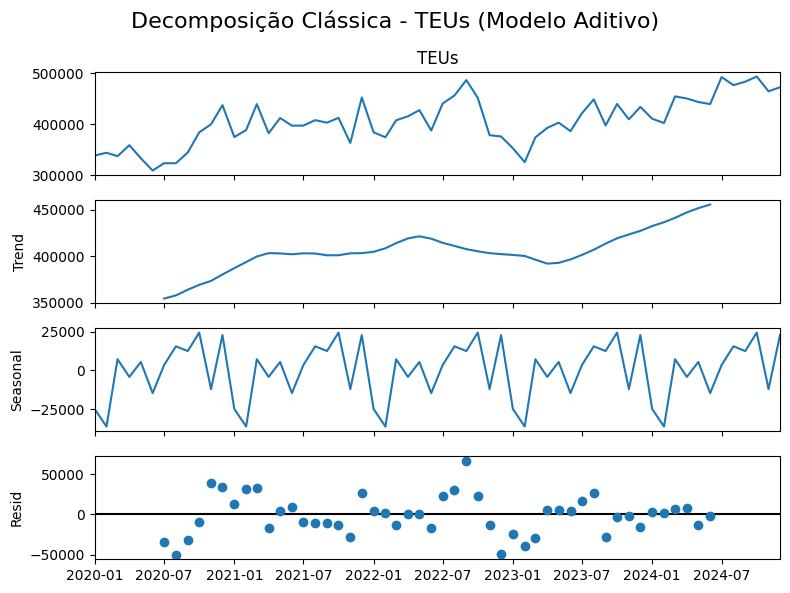

In [ ]:
# Decomposição clássica (aditiva)
decomp_add = seasonal_decompose(df_monthly["TEUs"], model="additive", period=12)

# Decomposição STL
stl = STL(df_monthly["TEUs"], period=12)
res_stl = stl.fit()

# Teste de estacionariedade ADF nos resíduos do modelo STL
adf_result = adfuller(res_stl.resid.dropna())
adf_statistic = adf_result[0]
adf_pvalue = adf_result[1]

# Organizando os resultados para exibição ao usuário
results_summary = {
    "ADF Statistic (STL Residuals)": adf_statistic,
    "p-value": adf_pvalue,
    "Conclusion": "Estacionária" if adf_pvalue < 0.05 else "Não Estacionária"
}

# Import ace_tools is not needed and can be removed
# import ace_tools as tools; tools.display_dataframe_to_user(name="Resumo do Teste de Estacionariedade (ADF)", dataframe=pd.DataFrame([results_summary]))

# Display the dataframe directly
pd.DataFrame([results_summary])

# Visualização da decomposição clássica
fig = decomp_add.plot()
fig.set_size_inches(8, 6)
plt.suptitle("Decomposição Clássica - TEUs (Modelo Aditivo)", fontsize=16)
plt.tight_layout()
plt.show()

3.2 Decomposição Clássica multiplicativa em Toneladas

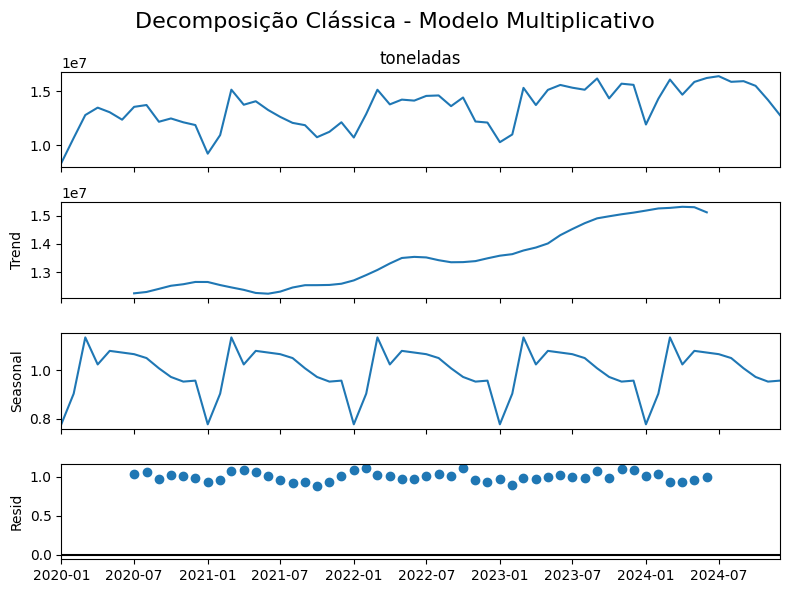

In [ ]:
# DECOMPOSIÇÃO CLÁSSICA - MODELO MULTIPLICATIVO
decomp_mult = seasonal_decompose(df_monthly["toneladas"], model="multiplicative", period=12)

fig = decomp_mult.plot()
fig.set_size_inches(8, 6)
plt.suptitle("Decomposição Clássica - Modelo Multiplicativo", fontsize=16)
plt.tight_layout()
plt.show()

3.2.1 Decomposição clássica multiplicativa em TEUs

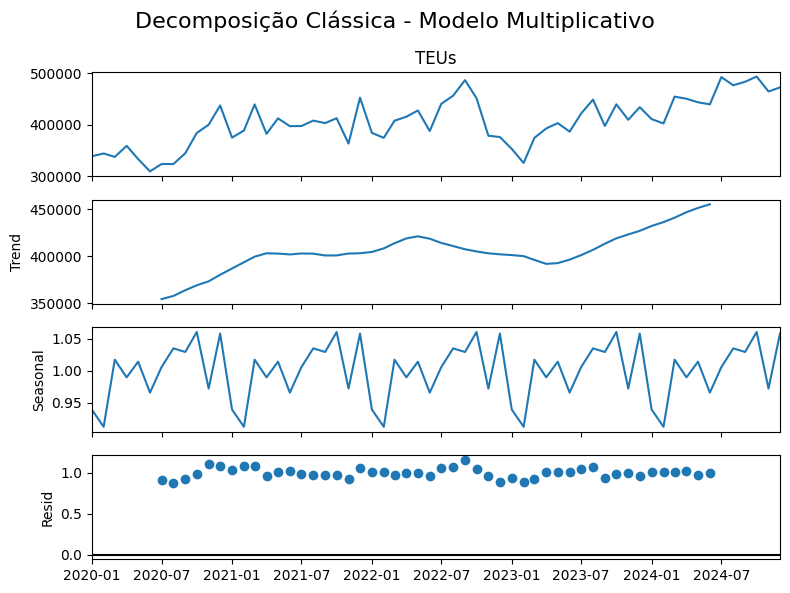

In [ ]:
# DECOMPOSIÇÃO CLÁSSICA - MODELO MULTIPLICATIVO
decomp_mult = seasonal_decompose(df_monthly["TEUs"], model="multiplicative", period=12)

fig = decomp_mult.plot()
fig.set_size_inches(8, 6)
plt.suptitle("Decomposição Clássica - Modelo Multiplicativo", fontsize=16)
plt.tight_layout()
plt.show()

3.3 Decomposição STL - Toneladas

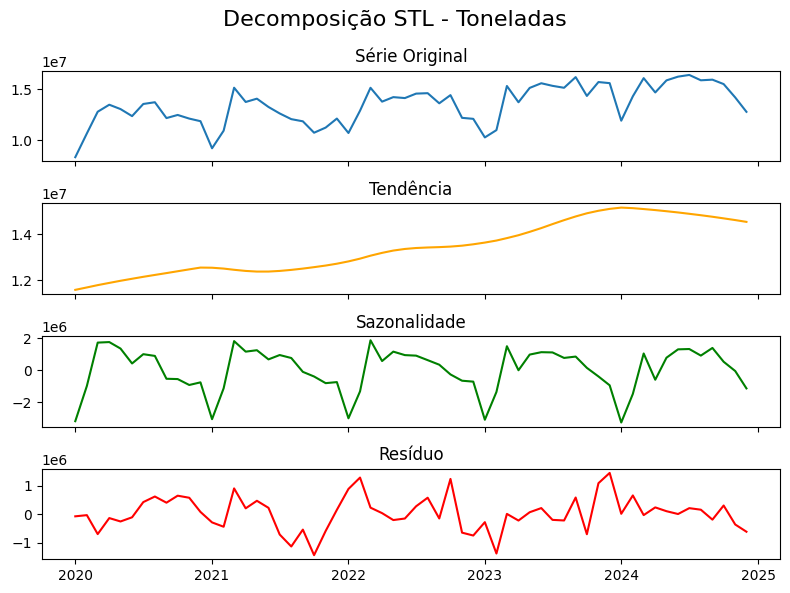

In [ ]:
# Visualização da decomposição STL
fig_stl, axs = plt.subplots(4, 1, figsize=(8, 6), sharex=True)
axs[0].plot(df_monthly["toneladas"], label="Original")
axs[0].set_title("Série Original")

axs[1].plot(res_stl.trend, label="Tendência", color="orange")
axs[1].set_title("Tendência")

axs[2].plot(res_stl.seasonal, label="Sazonalidade", color="green")
axs[2].set_title("Sazonalidade")

axs[3].plot(res_stl.resid, label="Resíduo", color="red")
axs[3].set_title("Resíduo")

plt.suptitle("Decomposição STL - Toneladas", fontsize=16)
plt.tight_layout()
plt.show()

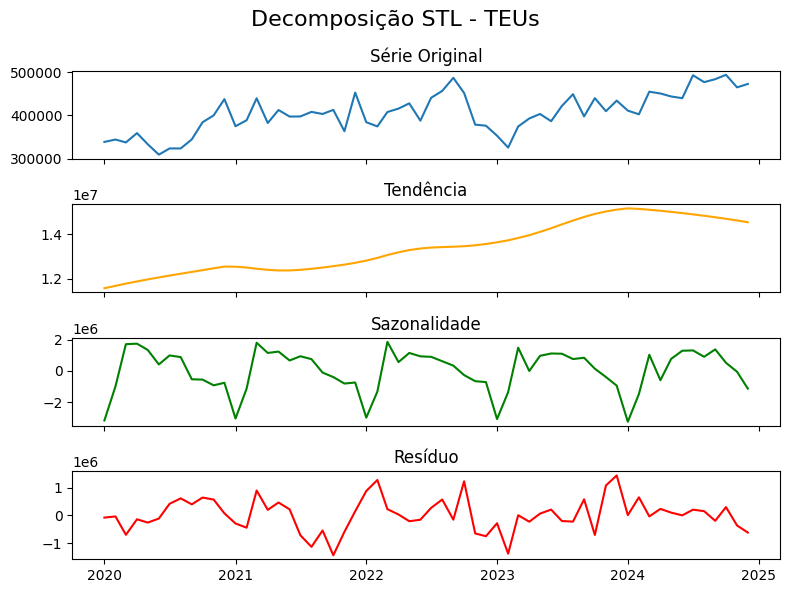

In [ ]:
# Visualização da decomposição STL
fig_stl, axs = plt.subplots(4, 1, figsize=(8, 6), sharex=True)
axs[0].plot(df_monthly["TEUs"], label="Original")
axs[0].set_title("Série Original")

axs[1].plot(res_stl.trend, label="Tendência", color="orange")
axs[1].set_title("Tendência")

axs[2].plot(res_stl.seasonal, label="Sazonalidade", color="green")
axs[2].set_title("Sazonalidade")

axs[3].plot(res_stl.resid, label="Resíduo", color="red")
axs[3].set_title("Resíduo")

plt.suptitle("Decomposição STL - TEUs", fontsize=16)
plt.tight_layout()
plt.show()

### **4 . Autocorrelação e Autocorrelação parcial**

**ACF (Autocorrelação)**: A ACF basicamente verifica o quanto os dados de hoje estão relacionados aos dados do passado. Em termos simples, ela ajuda a identificar se há padrões que se repetem, como ciclos ou tendências. No seu caso, quando a ACF mostra picos a cada 12 meses, isso indica que os dados de um mês têm uma relação forte com os dados de 12 meses atrás, confirmando que existe uma sazonalidade anual (ou seja, um padrão que se repete todo ano).

**PACF (Autocorrelação Parcial)**: A PACF também mede a relação entre os dados de hoje e os dados do passado, mas de uma maneira um pouco diferente. Ela “limpa” a influência de dados intermediários para entender melhor a relação direta entre o valor atual e o valor de um período específico no passado. Em termos simples, a PACF nos ajuda a entender melhor a "memória" que os dados têm de eventos passados, o que é útil para escolher o modelo certo para prever o futuro, como o **ARIMA** (um tipo de modelo que usa essa "memória" para fazer previsões).

Esses dois gráficos são muito importantes porque ajudam a entender o comportamento dos dados no tempo e ajudam a construir modelos de previsão mais precisos.


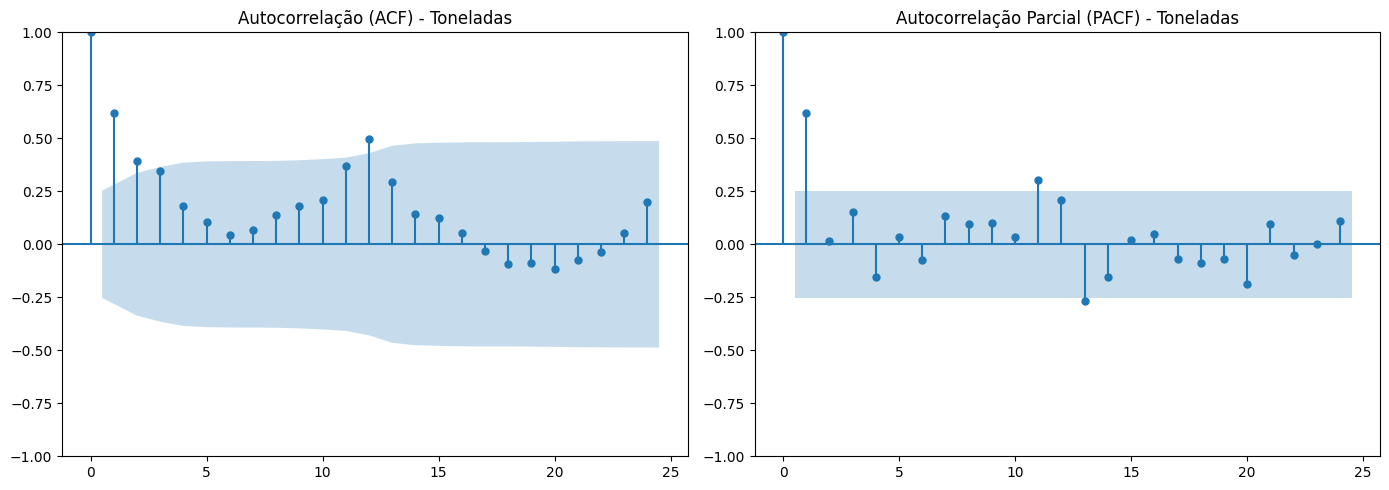

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Gráficos de ACF e PACF para a série de toneladas
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_acf(df_monthly["toneladas"], lags=24, ax=axes[0])
axes[0].set_title("Autocorrelação (ACF) - Toneladas")

plot_pacf(df_monthly["toneladas"], lags=24, ax=axes[1], method='ywm')
axes[1].set_title("Autocorrelação Parcial (PACF) - Toneladas")

plt.tight_layout()
plt.show()


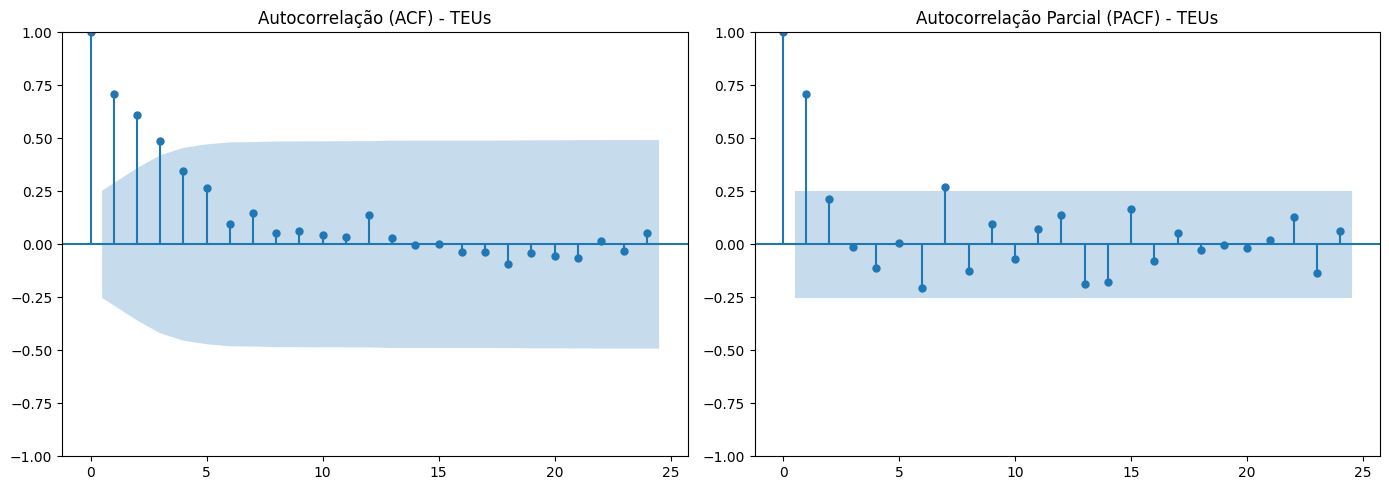

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Gráficos de ACF e PACF para a série de TEUs
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_acf(df_monthly["TEUs"], lags=24, ax=axes[0])
axes[0].set_title("Autocorrelação (ACF) - TEUs")

plot_pacf(df_monthly["TEUs"], lags=24, ax=axes[1], method='ywm')
axes[1].set_title("Autocorrelação Parcial (PACF) - TEUs")

plt.tight_layout()
plt.show()

4. Retirar a sazonalidade e comparar com a original.

df_mensal not found. Using df_monthly['toneladas'] instead.


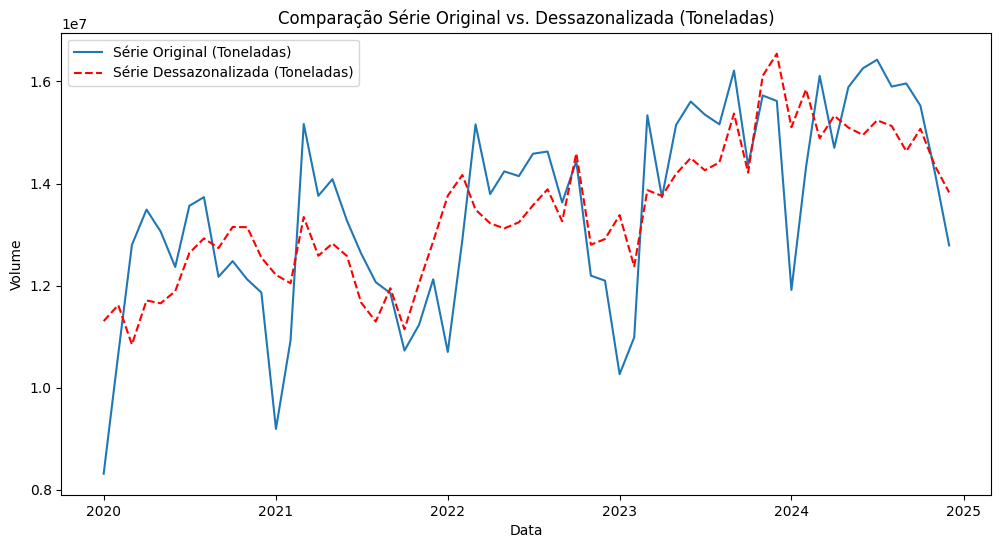


Teste ADF na Série Dessazonalizada (Toneladas):
ADF Statistic: -1.74
p-value: 0.412
Conclusão: Não Estacionária

Previsão ARIMA na Série Dessazonalizada (Toneladas):
2025-01-01    1.386358e+07
2025-02-01    1.386932e+07
2025-03-01    1.387016e+07
2025-04-01    1.387029e+07
2025-05-01    1.387031e+07
2025-06-01    1.387031e+07
Freq: MS, Name: predicted_mean, dtype: float64


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
DEBUG:cmdstanpy:input tempfile: /tmp/tmpetxourf7/84exa9f6.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpetxourf7/8zbf6ksf.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=29627', 'data', 'file=/tmp/tmpetxourf7/84exa9f6.json', 'init=/tmp


Previsão Prophet na Série Dessazonalizada (Toneladas) - sem sazonalidade interna do Prophet:
           ds          yhat
60 2025-01-01  1.541009e+07
61 2025-02-01  1.547537e+07
62 2025-03-01  1.553433e+07
63 2025-04-01  1.559961e+07
64 2025-05-01  1.566278e+07
65 2025-06-01  1.572805e+07


In [ ]:
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA # Import ARIMA
from prophet import Prophet # Import Prophet

# --- Dessazonalização da série de Toneladas ---

# Realizar a decomposição STL na série original de toneladas
# Assumindo que df_mensal exists and is your time series data
# If df_mensal is not defined, you might want to use df_monthly['toneladas'] or define df_mensal
try:
    stl_ton_dessaz = STL(df_mensal, seasonal=13) # Use o mesmo período sazonal (12 meses + 1)
except NameError:
    # Assuming df_mensal was intended to be df_monthly['toneladas']
    print("df_mensal not found. Using df_monthly['toneladas'] instead.")
    df_mensal = df_monthly['toneladas']
    stl_ton_dessaz = STL(df_mensal, seasonal=13) # Use o mesmo período sazonal (12 meses + 1)


res_ton_dessaz = stl_ton_dessaz.fit()

# A série dessazonalizada é (Original - Sazonalidade) + Média da série (opcional, para manter o nível)
# Ou mais simplesmente, a componente de Tendência + Resíduo
df_mensal_dessaz = res_ton_dessaz.trend + res_ton_dessaz.resid

# Remover valores NaN que podem surgir nas pontas após a decomposição
df_mensal_dessaz = df_mensal_dessaz.dropna()

# Visualizar a série original e a dessazonalizada
plt.figure(figsize=(12, 6))
plt.plot(df_mensal, label='Série Original (Toneladas)')
plt.plot(df_mensal_dessaz, label='Série Dessazonalizada (Toneladas)', color='red', linestyle='--')
plt.title('Comparação Série Original vs. Dessazonalizada (Toneladas)')
plt.xlabel('Data')
plt.ylabel('Volume')
plt.legend()
plt.show()

# Teste ADF na série dessazonalizada
adf_result_dessaz = adfuller(df_mensal_dessaz.dropna())
print("\nTeste ADF na Série Dessazonalizada (Toneladas):")
print(f"ADF Statistic: {adf_result_dessaz[0]:.2f}")
print(f"p-value: {adf_result_dessaz[1]:.3f}")
print(f"Conclusão: {'Estacionária' if adf_result_dessaz[1] < 0.05 else 'Não Estacionária'}")

# Ajustar modelo ARIMA na série dessazonalizada (ajuste a ordem (p,d,q) com base na análise da ACF/PACF da série dessazonalizada)
# Para este exemplo, vamos tentar um ARIMA simples (1,0,1) ou (1,1,1) dependendo do teste ADF
if adf_result_dessaz[1] < 0.05:
    # Série dessazonalizada é estacionária, usar d=0
    arima_ton_dessaz = ARIMA(df_mensal_dessaz, order=(1,0,1)).fit()
else:
    # Série dessazonalizada pode não ser estacionária, usar d=1
    arima_ton_dessaz = ARIMA(df_mensal_dessaz, order=(1,1,1)).fit()

# Prever valores futuros na série dessazonalizada
future_dates_dessaz = pd.date_range(start=df_mensal_dessaz.index[-1], periods=7, freq='MS')[1:] # 6 meses futuros
forecast_dessaz = arima_ton_dessaz.predict(start=future_dates_dessaz[0], end=future_dates_dessaz[-1])

print("\nPrevisão ARIMA na Série Dessazonalizada (Toneladas):")
print(forecast_dessaz)

# --- Aplicar Prophet na série dessazonalizada de Toneladas ---
# Embora Prophet seja bom com sazonalidade, aplicá-lo em uma série dessazonalizada
# não é o uso típico e pode não trazer benefícios, já que você já removeu a sazonalidade.
# No entanto, se você ainda quiser tentar, aqui está como seria:

prophet_df_ton_dessaz = df_mensal_dessaz.reset_index().rename(columns={'data': 'ds', 0: 'y'}) # 0 é o nome padrão da coluna após dropna
prophet_model_ton_dessaz = Prophet(seasonality_mode='additive', yearly_seasonality=False, weekly_seasonality=False, daily_seasonality=False) # Desligue a sazonalidade no Prophet
prophet_model_ton_dessaz.fit(prophet_df_ton_dessaz)
future_ton_dessaz = prophet_model_ton_dessaz.make_future_dataframe(periods=6, freq='MS')
forecast_ton_prophet_dessaz = prophet_model_ton_dessaz.predict(future_ton_dessaz)

print("\nPrevisão Prophet na Série Dessazonalizada (Toneladas) - sem sazonalidade interna do Prophet:")
print(forecast_ton_prophet_dessaz[['ds', 'yhat']].tail(6))

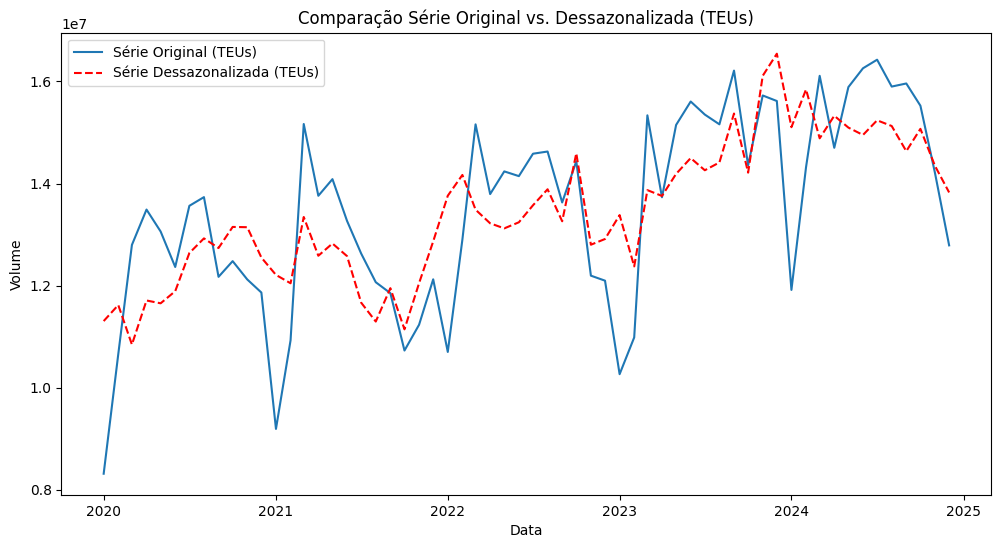

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
DEBUG:cmdstanpy:input tempfile: /tmp/tmpetxourf7/txl1t5kr.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpetxourf7/m95i61p1.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=43084', 'data', 'file=/tmp/tmpetxourf7/txl1t5kr.json', 'init=/tmp


Teste ADF na Série Dessazonalizada (TEUs):
ADF Statistic: -1.74
p-value: 0.412
Conclusão: Não Estacionária

Previsão ARIMA na Série Dessazonalizada (TEUs):
2025-01-01    1.386358e+07
2025-02-01    1.386932e+07
2025-03-01    1.387016e+07
2025-04-01    1.387029e+07
2025-05-01    1.387031e+07
2025-06-01    1.387031e+07
Freq: MS, Name: predicted_mean, dtype: float64


06:13:17 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing



Previsão Prophet na Série Dessazonalizada (TEUs) - sem sazonalidade interna do Prophet:
           ds          yhat
60 2025-01-01  1.541009e+07
61 2025-02-01  1.547537e+07
62 2025-03-01  1.553433e+07
63 2025-04-01  1.559961e+07
64 2025-05-01  1.566278e+07
65 2025-06-01  1.572805e+07


In [ ]:
try:
    stl_ton_dessaz = STL(df_mensal, seasonal=13) # Use o mesmo período sazonal (12 meses + 1)
except NameError:
    # Assuming df_mensal was intended to be df_monthly['TEUs']
    print("df_mensal not found. Using df_monthly['TEUs'] instead.")
    df_mensal = df_monthly['TEUs']
    stl_ton_dessaz = STL(df_mensal, seasonal=13) # Use o mesmo período sazonal (12 meses + 1)


res_ton_dessaz = stl_ton_dessaz.fit()

# A série dessazonalizada é (Original - Sazonalidade) + Média da série (opcional, para manter o nível)
# Ou mais simplesmente, a componente de Tendência + Resíduo
df_mensal_dessaz = res_ton_dessaz.trend + res_ton_dessaz.resid

# Remover valores NaN que podem surgir nas pontas após a decomposição
df_mensal_dessaz = df_mensal_dessaz.dropna()

# Visualizar a série original e a dessazonalizada
plt.figure(figsize=(12, 6))
plt.plot(df_mensal, label='Série Original (TEUs)')
plt.plot(df_mensal_dessaz, label='Série Dessazonalizada (TEUs)', color='red', linestyle='--')
plt.title('Comparação Série Original vs. Dessazonalizada (TEUs)')
plt.xlabel('Data')
plt.ylabel('Volume')
plt.legend()
plt.show()

# Teste ADF na série dessazonalizada
adf_result_dessaz = adfuller(df_mensal_dessaz.dropna())
print("\nTeste ADF na Série Dessazonalizada (TEUs):")
print(f"ADF Statistic: {adf_result_dessaz[0]:.2f}")
print(f"p-value: {adf_result_dessaz[1]:.3f}")
print(f"Conclusão: {'Estacionária' if adf_result_dessaz[1] < 0.05 else 'Não Estacionária'}")

# Ajustar modelo ARIMA na série dessazonalizada (ajuste a ordem (p,d,q) com base na análise da ACF/PACF da série dessazonalizada)
# Para este exemplo, vamos tentar um ARIMA simples (1,0,1) ou (1,1,1) dependendo do teste ADF
if adf_result_dessaz[1] < 0.05:
    # Série dessazonalizada é estacionária, usar d=0
    arima_ton_dessaz = ARIMA(df_mensal_dessaz, order=(1,0,1)).fit()
else:
    # Série dessazonalizada pode não ser estacionária, usar d=1
    arima_ton_dessaz = ARIMA(df_mensal_dessaz, order=(1,1,1)).fit()

# Prever valores futuros na série dessazonalizada
future_dates_dessaz = pd.date_range(start=df_mensal_dessaz.index[-1], periods=7, freq='MS')[1:] # 6 meses futuros
forecast_dessaz = arima_ton_dessaz.predict(start=future_dates_dessaz[0], end=future_dates_dessaz[-1])

print("\nPrevisão ARIMA na Série Dessazonalizada (TEUs):")
print(forecast_dessaz)

# --- Aplicar Prophet na série dessazonalizada de TEUs ---
# Embora Prophet seja bom com sazonalidade, aplicá-lo em uma série dessazonalizada
# não é o uso típico e pode não trazer benefícios, já que você já removeu a sazonalidade.
# No entanto, se você ainda quiser tentar, aqui está como seria:

prophet_df_ton_dessaz = df_mensal_dessaz.reset_index().rename(columns={'data': 'ds', 0: 'y'}) # 0 é o nome padrão da coluna após dropna
prophet_model_ton_dessaz = Prophet(seasonality_mode='additive', yearly_seasonality=False, weekly_seasonality=False, daily_seasonality=False) # Desligue a sazonalidade no Prophet
prophet_model_ton_dessaz.fit(prophet_df_ton_dessaz)
future_ton_dessaz = prophet_model_ton_dessaz.make_future_dataframe(periods=6, freq='MS')
forecast_ton_prophet_dessaz = prophet_model_ton_dessaz.predict(future_ton_dessaz)

print("\nPrevisão Prophet na Série Dessazonalizada (TEUs) - sem sazonalidade interna do Prophet:")
print(forecast_ton_prophet_dessaz[['ds', 'yhat']].tail(6))

5. Previsões em ARIMA e PROPHET

Dados de Treino: 2020-01-01 00:00:00 a 2023-12-01 00:00:00
Dados de Teste: 2024-01-01 00:00:00 a 2024-12-01 00:00:00

Teste ADF na Série Dessazonalizada (Treino):
ADF Statistic: -0.67
p-value: 0.854
Conclusão: Não Estacionária

Usando ordem ARIMA: (1, 1, 1) para série dessazonalizada.


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
DEBUG:cmdstanpy:input tempfile: /tmp/tmpetxourf7/3tb2png_.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpetxourf7/wqz0miz1.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=96630', 'data', 'file=/tmp/tmpetxourf7/3tb2png_.json', 'init=/tmp


Métricas para ARIMA (Dessazonalizado + Re-sazonalizado):
  MAE: 1055067.25
  RMSE: 1290496.28
  R2 Score: 0.1402
  Acurácia (baseada em MAE): 92.97%

Métricas para Prophet (Dessazonalizado + Re-sazonalizado):
  MAE: 619623.73
  RMSE: 855986.64
  R2 Score: 0.6217
  Acurácia (baseada em MAE): 95.87%


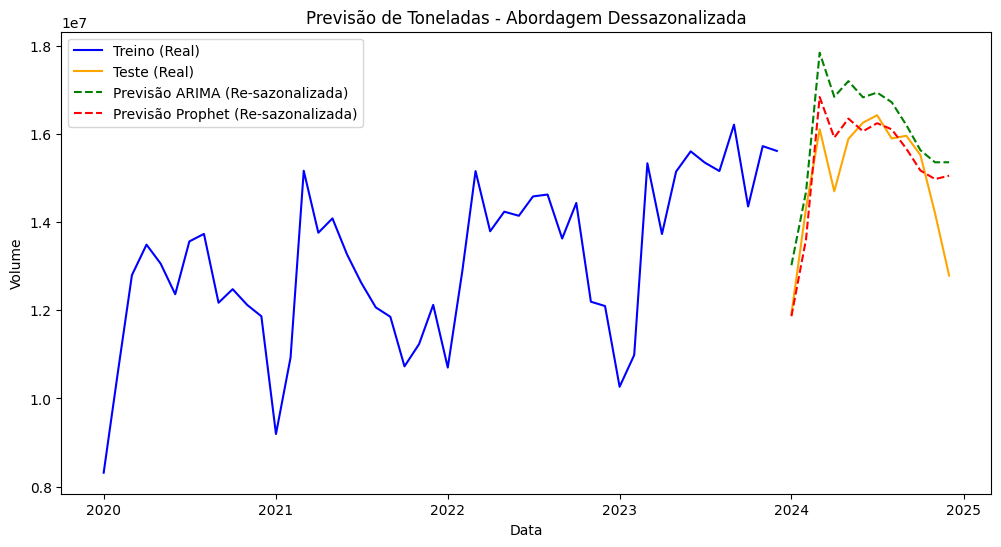

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.arima.model import ARIMA
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.tsa.stattools import adfuller


# --- Divisão Treino/Teste ---
# Vamos separar os últimos 12 meses para teste, similar ao seu código anterior de métricas.
train_size = len(df_mensal) - 12
train_data = df_mensal[:train_size]
test_data = df_mensal[train_size:]

print(f"Dados de Treino: {train_data.index.min()} a {train_data.index.max()}")
print(f"Dados de Teste: {test_data.index.min()} a {test_data.index.max()}")

# --- Dessazonalização dos Dados de Treino (para treinar os modelos) ---
# Aplicamos a decomposição STL apenas nos dados de treino
stl_train = STL(train_data, seasonal=13) # Use seasonal=13 para 12 meses + 1 ponto central
res_train = stl_train.fit()

# Série dessazonalizada do treino: Tendência + Resíduo
train_data_dessaz = res_train.trend + res_train.resid
train_data_dessaz = train_data_dessaz.dropna()

# --- Obter Componente Sazonal Média dos Dados de Treino (para re-sazonalização futura) ---
# Calculamos a média da componente sazonal para cada mês com base nos dados de treino
seasonal_component_mean = res_train.seasonal.groupby(res_train.seasonal.index.month).mean()

# --- Aplicar ARIMA na Série Dessazonalizada de Treino ---

# Teste ADF na série dessazonalizada de treino para ajudar a escolher a ordem (d)
adf_result_dessaz_train = adfuller(train_data_dessaz.dropna())
print("\nTeste ADF na Série Dessazonalizada (Treino):")
print(f"ADF Statistic: {adf_result_dessaz_train[0]:.2f}")
print(f"p-value: {adf_result_dessaz_train[1]:.3f}")
print(f"Conclusão: {'Estacionária' if adf_result_dessaz_train[1] < 0.05 else 'Não Estacionária'}")

# Ajustar modelo ARIMA na série dessazonalizada de treino
# Adapte a ordem (p,d,q) conforme a análise da série dessazonalizada de treino
arima_order = (1, 0, 1) # Ordem inicial sugerida se a série dessazonalizada for estacionária
if adf_result_dessaz_train[1] >= 0.05:
     arima_order = (1, 1, 1) # Se não for estacionária, considere d=1

print(f"\nUsando ordem ARIMA: {arima_order} para série dessazonalizada.")

arima_dessaz_model = ARIMA(train_data_dessaz, order=arima_order).fit()

# Prever valores futuros na série dessazonalizada para o período de teste
forecast_dessaz_arima = arima_dessaz_model.predict(start=test_data.index[0], end=test_data.index[-1])

# --- Re-sazonalização da Previsão ARIMA ---
# Adicionar a componente sazonal média correspondente de volta à previsão dessazonalizada
forecast_arima_resaz = forecast_dessaz_arima.copy()
for date in forecast_arima_resaz.index:
    month = date.month
    forecast_arima_resaz.loc[date] += seasonal_component_mean.loc[month]

# --- Aplicar Prophet na Série Dessazonalizada de Treino ---

# Verify the column names before renaming
# print(train_data_dessaz.reset_index().columns)

# The column containing the index (dates) will be named 'index' after reset_index() by default.
# The column containing the series values might retain its original name if it had one,
# but if it was a simple Series created from addition/subtraction, it might be 0.
# Let's rename the index column to 'ds' and assume the value column is named 0 or already 'y'.
# A more robust way is to explicitly name the series before dropna or reset_index.
# Let's assume after dropna it's still a Series and reset_index makes the data column 'index' and the values '0'
# Based on the traceback and global variables, it seems the index column became 'data'. Let's adjust the rename.

# Original line causing the error:
# prophet_df_train_dessaz = train_data_dessaz.reset_index().rename(columns={'index': 'ds', 0: 'y'})

# Corrected line assuming index becomes 'data' and values become '0' after reset_index on a Series
prophet_df_train_dessaz = train_data_dessaz.reset_index().rename(columns={'data': 'ds', 0: 'y'})


prophet_dessaz_model = Prophet(seasonality_mode='additive', yearly_seasonality=False, weekly_seasonality=False, daily_seasonality=False) # Desligue a sazonalidade interna
prophet_dessaz_model.fit(prophet_df_train_dessaz)

# Criar datas futuras para previsão no período de teste
future_dessaz_prophet = prophet_dessaz_model.make_future_dataframe(periods=len(test_data), freq='MS')
forecast_dessaz_prophet = prophet_dessaz_model.predict(future_dessaz_prophet)

# Filtrar a previsão para o período de teste
forecast_dessaz_prophet_test = forecast_dessaz_prophet.set_index('ds').loc[test_data.index]['yhat']

# --- Re-sazonalização da Previsão Prophet ---
forecast_prophet_resaz = forecast_dessaz_prophet_test.copy()
for date in forecast_prophet_resaz.index:
    month = date.month
    forecast_prophet_resaz.loc[date] += seasonal_component_mean.loc[month]


# --- Cálculo de Métricas de Avaliação ---
def calcular_metricas(y_true, y_pred, nome_modelo):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    media_real = np.mean(y_true)
    # A acurácia percentual baseada em MAE pode ser calculada como 1 - (MAE / Média Real)
    acc_mae = 100 * (1 - mae / media_real)

    print(f"\nMétricas para {nome_modelo}:")
    print(f"  MAE: {mae:.2f}")
    print(f"  RMSE: {rmse:.2f}")
    print(f"  R2 Score: {r2:.4f}")
    print(f"  Acurácia (baseada em MAE): {acc_mae:.2f}%")

# Calcular métricas para ARIMA (re-sazonalizado)
calcular_metricas(test_data, forecast_arima_resaz, "ARIMA (Dessazonalizado + Re-sazonalizado)")

# Calcular métricas para Prophet (re-sazonalizado)
calcular_metricas(test_data, forecast_prophet_resaz, "Prophet (Dessazonalizado + Re-sazonalizado)")


# --- Opcional: Visualizar as Previsões Re-sazonalizadas vs. Real ---
plt.figure(figsize=(12, 6))
plt.plot(train_data, label='Treino (Real)', color='blue')
plt.plot(test_data, label='Teste (Real)', color='orange')
plt.plot(forecast_arima_resaz, label='Previsão ARIMA (Re-sazonalizada)', color='green', linestyle='--')
plt.plot(forecast_prophet_resaz, label='Previsão Prophet (Re-sazonalizada)', color='red', linestyle='--')
plt.title('Previsão de Toneladas - Abordagem Dessazonalizada')
plt.xlabel('Data')
plt.ylabel('Volume')
plt.legend()
plt.show()

Dados de Treino (TEUs): 2020-01-01 00:00:00 a 2023-12-01 00:00:00
Dados de Teste (TEUs): 2024-01-01 00:00:00 a 2024-12-01 00:00:00

Teste ADF na Série Dessazonalizada (Treino - TEUs):
ADF Statistic: -2.89
p-value: 0.046
Conclusão: Estacionária

Usando ordem ARIMA: (1, 0, 1) para série dessazonalizada (TEUs).


DEBUG:cmdstanpy:input tempfile: /tmp/tmpetxourf7/1ffhvqhi.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpetxourf7/1rt6bb3t.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=20188', 'data', 'file=/tmp/tmpetxourf7/1ffhvqhi.json', 'init=/tmp/tmpetxourf7/1rt6bb3t.json', 'output', 'file=/tmp/tmpetxourf7/prophet_modellnll5b9t/prophet_model-20250611062504.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
06:25:04 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
06:25:04 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing



Métricas para ARIMA (Dessazonalizado + Re-sazonalizado - TEUs):
  MAE: 47539.36
  RMSE: 52572.74
  R2 Score: -2.4342
  Acurácia (baseada em MAE): 89.60%

Métricas para Prophet (Dessazonalizado + Re-sazonalizado - TEUs):
  MAE: 58451.91
  RMSE: 61593.23
  R2 Score: -3.7138
  Acurácia (baseada em MAE): 87.21%


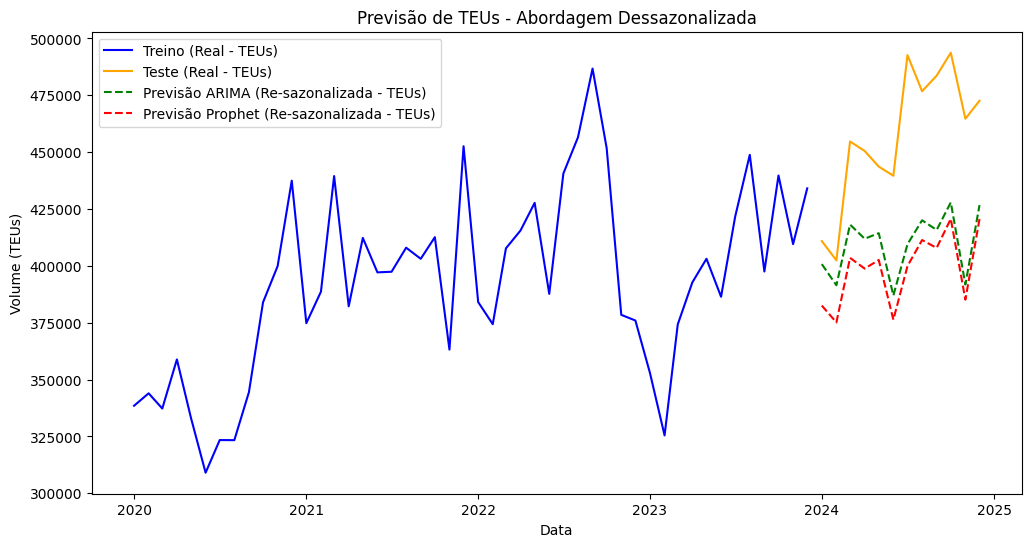

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.arima.model import ARIMA
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.tsa.stattools import adfuller

# --- Ensure df_teus_mensal is created ---
# It seems this DataFrame was not created earlier. Let's create it here.
# Assuming 'df' DataFrame with 'ano', 'mes', 'TEUs' columns is available from previous steps.
try:
    # Check if df_monthly is available and contains 'TEUs'
    df_teus_mensal = df_monthly['TEUs'].asfreq('MS')
except NameError:
    # If df_monthly is not available, read and process from the excel file
    print("df_monthly not found. Reading and processing 'Dados_completos.xlsx' to create df_teus_mensal.")
    try:
        df = pd.read_excel('Dados_completos.xlsx')
        df = df[df['ano'].between(2020, 2024)].copy() # Use .copy() to avoid SettingWithCopyWarning
        df['data'] = pd.to_datetime(df['ano'].astype(str) + '-' + df['mes'].astype(str).str.zfill(2) + '-01')
        df['TEUs'] = pd.to_numeric(df['TEUs'], errors='coerce')
        df.dropna(subset=['TEUs'], inplace=True)
        df_teus_mensal = df.groupby('data')['TEUs'].sum().asfreq('MS')
    except FileNotFoundError:
        print("Error: 'Dados_completos.xlsx' not found.")
        # You might want to exit or handle this error appropriately
        raise
    except Exception as e:
        print(f"An error occurred during data processing: {e}")
        raise


# --- Divisão Treino/Teste (TEUs) ---
# Vamos separar os últimos 12 meses para teste
train_size_teus = len(df_teus_mensal) - 12
train_data_teus = df_teus_mensal[:train_size_teus]
test_data_teus = df_teus_mensal[train_size_teus:]

print(f"Dados de Treino (TEUs): {train_data_teus.index.min()} a {train_data_teus.index.max()}")
print(f"Dados de Teste (TEUs): {test_data_teus.index.min()} a {test_data_teus.index.max()}")

# --- Dessazonalização dos Dados de Treino (TEUs) ---
stl_train_teus = STL(train_data_teus, seasonal=13)
res_train_teus = stl_train_teus.fit()

train_data_dessaz_teus = res_train_teus.trend + res_train_teus.resid
train_data_dessaz_teus = train_data_dessaz_teus.dropna()

# --- Obter Componente Sazonal Média dos Dados de Treino (TEUs) ---
seasonal_component_mean_teus = res_train_teus.seasonal.groupby(res_train_teus.seasonal.index.month).mean()

# --- Aplicar ARIMA na Série Dessazonalizada de Treino (TEUs) ---
adf_result_dessaz_train_teus = adfuller(train_data_dessaz_teus.dropna())
print("\nTeste ADF na Série Dessazonalizada (Treino - TEUs):")
print(f"ADF Statistic: {adf_result_dessaz_train_teus[0]:.2f}")
print(f"p-value: {adf_result_dessaz_train_teus[1]:.3f}")
print(f"Conclusão: {'Estacionária' if adf_result_dessaz_train_teus[1] < 0.05 else 'Não Estacionária'}")

arima_order_teus = (1, 0, 1)
if adf_result_dessaz_train_teus[1] >= 0.05:
     arima_order_teus = (1, 1, 1)

print(f"\nUsando ordem ARIMA: {arima_order_teus} para série dessazonalizada (TEUs).")

arima_dessaz_model_teus = ARIMA(train_data_dessaz_teus, order=arima_order_teus).fit()

forecast_dessaz_arima_teus = arima_dessaz_model_teus.predict(start=test_data_teus.index[0], end=test_data_teus.index[-1])

# --- Re-sazonalização da Previsão ARIMA (TEUs) ---
forecast_arima_resaz_teus = forecast_dessaz_arima_teus.copy()
for date in forecast_arima_resaz_teus.index:
    month = date.month
    forecast_arima_resaz_teus.loc[date] += seasonal_component_mean_teus.loc[month]

# --- Aplicar Prophet na Série Dessazonalizada de Treino (TEUs) ---
prophet_df_train_dessaz_teus = train_data_dessaz_teus.reset_index().rename(columns={'data': 'ds', 0: 'y'})

prophet_dessaz_model_teus = Prophet(seasonality_mode='additive', yearly_seasonality=False, weekly_seasonality=False, daily_seasonality=False)
prophet_dessaz_model_teus.fit(prophet_df_train_dessaz_teus)

future_dessaz_prophet_teus = prophet_dessaz_model_teus.make_future_dataframe(periods=len(test_data_teus), freq='MS')
forecast_dessaz_prophet_teus = prophet_dessaz_model_teus.predict(future_dessaz_prophet_teus)

forecast_dessaz_prophet_test_teus = forecast_dessaz_prophet_teus.set_index('ds').loc[test_data_teus.index]['yhat']

# --- Re-sazonalização da Previsão Prophet (TEUs) ---
forecast_prophet_resaz_teus = forecast_dessaz_prophet_test_teus.copy()
for date in forecast_prophet_resaz_teus.index:
    month = date.month
    forecast_prophet_resaz_teus.loc[date] += seasonal_component_mean_teus.loc[month]

# --- Cálculo de Métricas de Avaliação (TEUs) ---
def calcular_metricas(y_true, y_pred, nome_modelo):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    media_real = np.mean(y_true)
    acc_mae = 100 * (1 - mae / media_real)

    print(f"\nMétricas para {nome_modelo}:")
    print(f"  MAE: {mae:.2f}")
    print(f"  RMSE: {rmse:.2f}")
    print(f"  R2 Score: {r2:.4f}")
    print(f"  Acurácia (baseada em MAE): {acc_mae:.2f}%")

calcular_metricas(test_data_teus, forecast_arima_resaz_teus, "ARIMA (Dessazonalizado + Re-sazonalizado - TEUs)")
calcular_metricas(test_data_teus, forecast_prophet_resaz_teus, "Prophet (Dessazonalizado + Re-sazonalizado - TEUs)")

# --- Visualizar as Previsões Re-sazonalizadas vs. Real (TEUs) ---
plt.figure(figsize=(12, 6))
plt.plot(train_data_teus, label='Treino (Real - TEUs)', color='blue')
plt.plot(test_data_teus, label='Teste (Real - TEUs)', color='orange')
plt.plot(forecast_arima_resaz_teus, label='Previsão ARIMA (Re-sazonalizada - TEUs)', color='green', linestyle='--')
plt.plot(forecast_prophet_resaz_teus, label='Previsão Prophet (Re-sazonalizada - TEUs)', color='red', linestyle='--')
plt.title('Previsão de TEUs - Abordagem Dessazonalizada')
plt.xlabel('Data')
plt.ylabel('Volume (TEUs)')
plt.legend()
plt.show()

6. Meses com baixa movimentação e sazonalidade

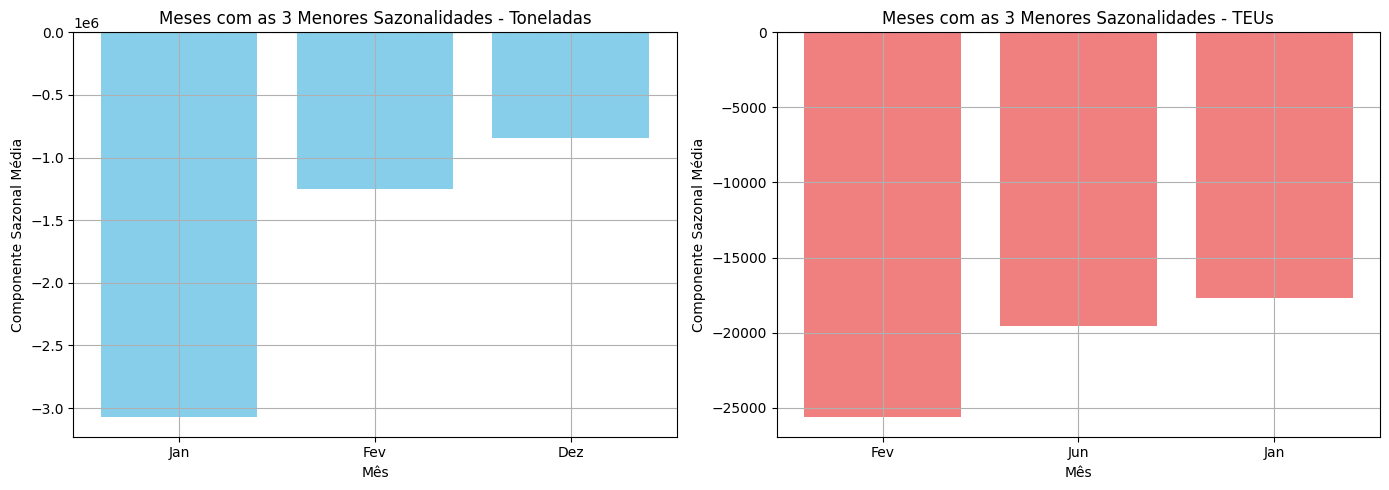

In [ ]:
num_meses_baixa = 3

try:
    sazonal_por_mes_toneladas = df_monthly.groupby(df_monthly.index.month)["sazonal_toneladas"].mean()
    sazonal_por_mes_teus = df_monthly.groupby(df_monthly.index.month)["sazonal_TEUs"].mean()
except KeyError:
    print("As colunas 'sazonal_toneladas' ou 'sazonal_TEUs' não foram encontradas.")
    print("Certifique-se de que a decomposição STL e o cálculo da componente sazonal foram executados antes deste bloco.")
    # Pode ser necessário recalcular ou lidar com a ausência dos dados

# Identifique os meses com a menor sazonalidade
ton_baixa = sazonal_por_mes_toneladas.nsmallest(num_meses_baixa) # Pega os 'num_meses_baixa' menores
teus_baixa = sazonal_por_mes_teus.nsmallest(num_meses_baixa) # Pega os 'num_meses_baixa' menores

# --- Defina o dicionário 'meses' ---
meses = {
    1: 'Jan', 2: 'Fev', 3: 'Mar', 4: 'Abr', 5: 'Mai', 6: 'Jun',
    7: 'Jul', 8: 'Ago', 9: 'Set', 10: 'Out', 11: 'Nov', 12: 'Dez'
}


# --- Código Original para Plotagem (agora com variáveis definidas) ---

# Gráfico de meses com menor sazonalidade
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico para Toneladas
axs[0].bar([meses[m] for m in ton_baixa.index], ton_baixa.values, color='skyblue')
axs[0].set_title(f'Meses com as {num_meses_baixa} Menores Sazonalidades - Toneladas')
axs[0].set_ylabel('Componente Sazonal Média')
axs[0].set_xlabel('Mês')
axs[0].grid(True)
axs[0].axhline(0, color='gray', linestyle='--') # Adiciona linha de referência no zero

# Gráfico para TEUs
axs[1].bar([meses[m] for m in teus_baixa.index], teus_baixa.values, color='lightcoral')
axs[1].set_title(f'Meses com as {num_meses_baixa} Menores Sazonalidades - TEUs')
axs[1].set_ylabel('Componente Sazonal Média')
axs[1].set_xlabel('Mês')
axs[1].grid(True)
axs[1].axhline(0, color='gray', linestyle='--') # Adiciona linha de referência no zero


plt.tight_layout()
plt.show()

## 7. **Conclusão**

Este estudo utilizou técnicas de decomposição de séries temporais para identificar padrões sazonais nas movimentações mensais de toneladas e TEUs nos portos. A análise foi realizada utilizando os modelos clássicos aditivo e multiplicativo, além do modelo STL, permitindo:

* Isolar claramente os componentes de tendência e sazonalidade;
* Confirmar que os resíduos do modelo STL são estacionários (teste ADF), validando a robustez do modelo;
* Identificar com precisão os períodos de baixa movimentação logística.

O modelo STL se destacou por sua flexibilidade e capacidade de capturar variações sazonais e de tendência de forma não linear. Este tipo de análise é particularmente valioso para otimizar operações portuárias, ajustar capacidades e reduzir custos durante períodos de baixa demanda.

Os meses de **janeiro, fevereiro e dezembro** apresentaram menor movimentação em **toneladas**, enquanto **janeiro, fevereiro e junho** destacaram-se como os meses de menor movimentação em **TEUs**.

Vale ressaltar que o modelo Arima foi melhor em TEUs e o modelo Prophet foi melhor em toneladas.

Os meses de menor sazonalidade continuarão sendo os mesmos que você identificou na etapa inicial de decomposição, pois essa identificação se baseia no padrão repetitivo da série original, e não nas previsões feitas na série já modificada (dessazonalizada).
Essas informações são fundamentais para:

* Reduzir custos operacionais nos meses de baixa demanda;
* Replanejar a mão de obra e a frota logística;
* Negociar contratos mais flexíveis com fornecedores.

Assim, a decomposição da série temporal não só explica o comportamento histórico, mas também oferece informações valiosas para o planejamento estratégico.
